# 01 — Basic S&P 500 Data

**Goal of this notebook:** load the longest, cleanest S&P 500 *total-return* data we can get, look at it, and plot the growth of $1. Nothing fancy yet — we are just getting comfortable with the data.

**Key idea — total return vs price:** the *price* index (like the number you see on TV) ignores dividends. The *total-return* index reinvests dividends, so it reflects what a real buy-and-hold investor actually earns. We use total return everywhere we can.

In [1]:
# --- standard setup (run me first) ---
import sys, os
# Make the project root importable so `from src import ...` works from notebooks/.
sys.path.insert(0, os.path.abspath(".."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Setup complete. Project root:", os.path.abspath(".."))

Setup complete. Project root: C:\Users\Taffy Jackson\leveraged-trend-following


## Load the data

`data_loader.get_underlying_total_return()` tries, in order:
1. `^SP500TR` — the true daily S&P 500 Total Return index (from 1988),
2. `SPY` adjusted close — an investable proxy (from 1993),
3. a clearly-labelled **synthetic** series (only if you are offline).

Data is cached in `data/raw`, so this is instant after the first run.

In [2]:
from src import data_loader as dl, data_cleaning as dc, returns as rt
from src import metrics as mx, plots as pl

underlying, ticker, source = dl.get_underlying_total_return()
print('Series :', ticker)
print('Source :', source)
print('Range  :', underlying.index.min().date(), '->', underlying.index.max().date())
print('Points :', len(underlying))

Series : ^SP500TR
Source : Yahoo Finance ^SP500TR (true daily total return)
Range  : 1988-01-04 -> 2026-06-08
Points : 9680


## Clean it and build the data-summary table

Cleaning = sort dates, drop duplicates, trim missing values, and *report* every decision. We also load the wider universe (proxies, leveraged ETFs, T-bills) just to summarise what data exists.

In [3]:
tickers = ['^SP500TR','SPY','^GSPC','^IRX','SSO','UPRO','SPXL','VOO','IVV','SPLG']
raw = dl.load_universe(tickers)
clean, reports = dc.clean_universe(raw)
summary = dc.build_data_summary(clean, reports)
summary[['ticker','role','leverage','first_date','last_date','n_observations','kind','source']]

,ticker,role,leverage,first_date,last_date,n_observations,kind,source
0,^GSPC,context,1.0000,1927-12-30,2026-06-08,24725,Price only (no dividends),Yahoo Finance
1,SPXL,leveraged,3.0000,2008-11-05,2026-06-08,4423,Adjusted price (=TR),Yahoo Finance
2,SSO,leveraged,2.0000,2006-06-21,2026-06-08,5022,Adjusted price (=TR),Yahoo Finance
3,UPRO,leveraged,3.0000,2009-06-25,2026-06-08,4264,Adjusted price (=TR),Yahoo Finance
4,IVV,proxy_1x,1.0000,2000-05-19,2026-06-08,6551,Adjusted price (=TR),Yahoo Finance
5,SPLG,proxy_1x,1.0000,2009-01-02,2026-06-08,4383,Adjusted price (=TR),Yahoo Finance
6,SPY,proxy_1x,1.0000,1993-01-29,2026-06-08,8396,Adjusted price (=TR),Yahoo Finance
7,VOO,proxy_1x,1.0000,2010-09-09,2026-06-08,3960,Adjusted price (=TR),Yahoo Finance
8,^IRX,rf,0.0000,1960-01-04,2026-06-08,16622,Interest rate (%),Yahoo Finance
9,^SP500TR,underlying,1.0000,1988-01-04,2026-06-08,9680,Total return,Yahoo Finance


Notice the different histories: the price-only `^GSPC` reaches back to 1927, the total-return `^SP500TR` to 1988, and the leveraged ETFs (SSO 2006, SPXL 2008, UPRO 2009) are much younger. This is why we lean on the synthetic-leverage backtest for long history and use the real ETFs as a reality check (notebook 06).

## Daily returns and the growth of $1

First few daily returns:
Date
1988-01-05    0.0107
1988-01-06    0.0010
1988-01-07    0.0084
1988-01-08   -0.0676
1988-01-11    0.0169
Name: ^SP500TR, dtype: float64


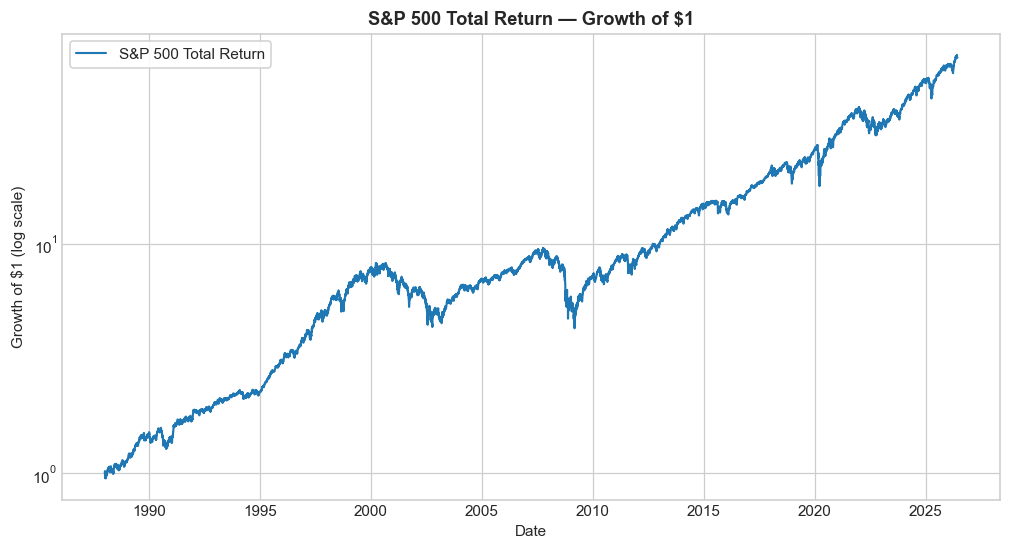

In [4]:
u = rt.simple_returns(underlying)
print('First few daily returns:')
print(u.head())

fig = pl.plot_cumulative({'S&P 500 Total Return': underlying},
                         'S&P 500 Total Return — Growth of $1',
                         '01_sp500_cumulative.png', log=True)
plt.show()

**Why a log scale?** On a log axis, a straight line means a *constant percentage* growth rate. Equal vertical distances are equal multiples (e.g. doubling), which is the honest way to look at decades of compounding. We will use log scales for almost every equity curve.

➡️ **Next:** notebook 02 turns this series into proper performance statistics (CAGR, volatility, Sharpe, drawdown).